# 06 — Classification: Theory and Methods
**Goal:** Build the three classical classifiers (logistic regression, LDA,
QDA) from the same probabilistic foundation, then add the metrics that
make sense for classification. Source: ISLR Ch4, Bishop Ch4, Murphy Ch8.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
np.random.seed(6)

## 1. The classification setup

Output y takes one of K values (most commonly K=2). We want either

- a **discriminant** function f(x) that returns a class label, or
- a **probabilistic** estimate p(y | x) that we can threshold.

**Three classical approaches that share a probabilistic core:**

| Model | Model of x \| y | Decision boundary |
|---|---|---|
| Logistic regression | discriminative: P(y\|x) | linear |
| LDA | generative: P(x\|y) Gaussian, shared Σ | linear |
| QDA | generative: P(x\|y) Gaussian, per-class Σ | quadratic |
| Naive Bayes | generative: P(x\|y) = Π P(xⱼ\|y) | linear (often) |

## 2. Logistic regression

Model:
    P(y = 1 | x) = σ(w⊤x + b) = 1 / (1 + exp(-(w⊤x + b)))

Log-likelihood for n i.i.d. samples:
    ℓ(w) = Σᵢ [yᵢ log pᵢ + (1 - yᵢ) log(1 - pᵢ)],   pᵢ = σ(w⊤xᵢ + b)

No closed form. Optimized by gradient descent, IRLS, or L-BFGS. The loss is
convex — unique global optimum.

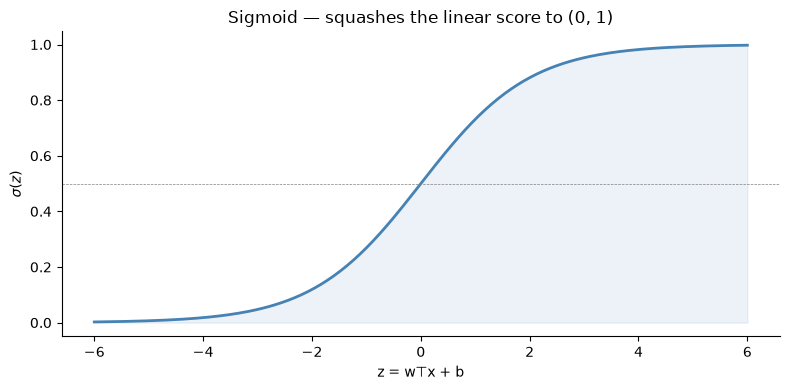

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-6, 6, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z, sigmoid(z), color='steelblue', lw=2)
ax.fill_between(z, 0, sigmoid(z), alpha=0.1, color='steelblue')
ax.axhline(0.5, color='gray', lw=0.5, linestyle='--')
ax.set_xlabel('z = w\u22a4x + b'); ax.set_ylabel(r'$\sigma(z)$')
ax.set_title('Sigmoid — squashes the linear score to (0, 1)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 3. The decision boundary

Classify to the class with the higher probability:

    ŷ = 1   iff   P(y=1|x) > 0.5   iff   w⊤x + b > 0

The set {x : w⊤x + b = 0} is the **decision boundary** — a hyperplane.
Logistic regression is a *linear* classifier.

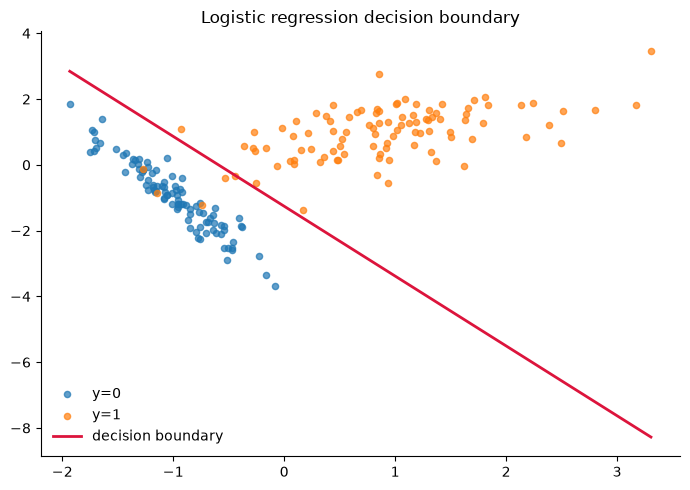

In [3]:
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=6)
clf = LogisticRegression().fit(X, y)
w, b = clf.coef_[0], clf.intercept_[0]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=20, alpha=0.7, label='y=0')
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=20, alpha=0.7, label='y=1')
xs = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
ax.plot(xs, -(w[0] * xs + b) / w[1], color='crimson', lw=2, label='decision boundary')
ax.legend(frameon=False)
ax.set_title('Logistic regression decision boundary')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 4. LDA — linear discriminant analysis

Assume X | Y = k ~ N(μₖ, Σ) with the **same** covariance matrix in every
class. Bayes' rule gives

    P(Y = k | X = x)  ∝  πₖ · N(x; μₖ, Σ)

Taking logs and using log N(x; μ, Σ) = -½(x-μ)⊤Σ⁻¹(x-μ) + const, the
k-vs-l decision rule reduces to

    x⊤Σ⁻¹(μₖ - μₗ) - ½(μₖ⊤Σ⁻¹μₖ - μₗ⊤Σ⁻¹μₗ) + log(πₖ/πₗ)  >  0

This is *linear* in x. Empirically, plug in sample means, common Σ̂, and
class priors π̂ₖ = nₖ / n.

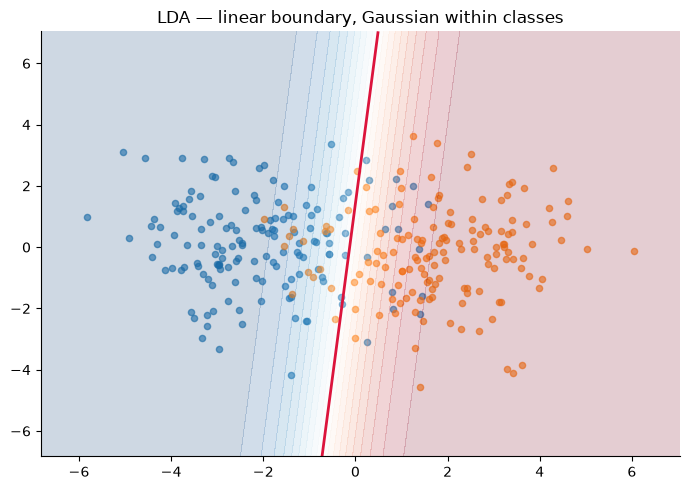

In [4]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=300, centers=[[-2, 0], [2, 0]], cluster_std=1.5, random_state=0)
lda = LinearDiscriminantAnalysis().fit(X, y)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=20, alpha=0.6)
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=20, alpha=0.6)
x_grid = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
xx, yy = np.meshgrid(x_grid, x_grid)
zz = lda.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
ax.contour(xx, yy, zz, levels=[0.5], colors='crimson', linewidths=2)
ax.contourf(xx, yy, zz, levels=20, cmap='RdBu_r', alpha=0.2)
ax.set_title('LDA — linear boundary, Gaussian within classes')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 5. QDA — when classes have different shapes

If each class has its own covariance Σₖ, the discriminant function picks up
a quadratic term in x and the decision boundary becomes a conic section
(ellipse, parabola, hyperbola, or pair of lines).

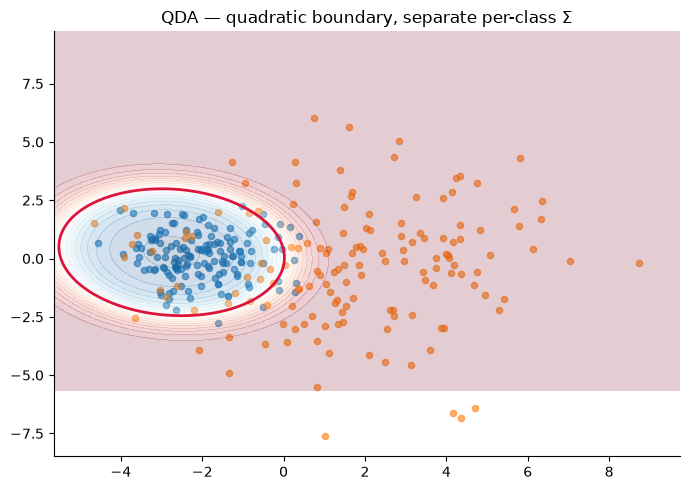

In [5]:
X, y = make_blobs(n_samples=300, centers=[[-2, 0], [2, 0]],
                  cluster_std=[1.0, 2.5], random_state=0)
qda = QuadraticDiscriminantAnalysis().fit(X, y)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=20, alpha=0.6)
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=20, alpha=0.6)
x_grid = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
xx, yy = np.meshgrid(x_grid, x_grid)
zz = qda.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
ax.contour(xx, yy, zz, levels=[0.5], colors='crimson', linewidths=2)
ax.contourf(xx, yy, zz, levels=20, cmap='RdBu_r', alpha=0.2)
ax.set_title('QDA — quadratic boundary, separate per-class \u03a3')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 6. The bias-variance of LDA vs QDA

QDA has **p(p+1)/2 parameters per class** for the covariance; LDA shares
them, so QDA has more parameters and is more flexible — and more
data-hungry.

| | LDA | QDA |
|---|---|---|
| Decision boundary | linear | quadratic |
| # params (per class Σ) | p(p+1)/2 | p(p+1)/2 |
| Shared across classes | yes | no |
| Bias | higher | lower |
| Variance | lower | higher |
| Use when | small n, classes similar | large n, classes differ in shape |

A useful diagnostic: fit both; if the training error of QDA is much lower
than LDA's but test error is similar or worse, the extra flexibility is
just fitting noise.

## 7. Confusion matrix and metrics

For binary classification with positive class = 1:

| | predicted 0 | predicted 1 |
|---|---|---|
| **actual 0** | TN | FP |
| **actual 1** | FN | TP |

From these:
  - **Accuracy**        = (TP + TN) / n       (useless on imbalanced data)
  - **Precision**       = TP / (TP + FP)      ("of the positives I predicted, how many are right?")
  - **Recall (TPR)**    = TP / (TP + FN)      ("of the real positives, how many did I catch?")
  - **F1**              = 2 · P · R / (P + R)
  - **Specificity (TNR)** = TN / (TN + FP)
  - **FPR**             = FP / (TN + FP)      = 1 - TNR

/Volumes/SSD_Gabo/proyectos/learning_courses/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


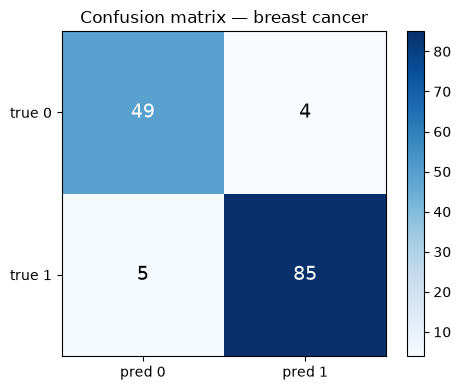

              precision    recall  f1-score   support

   malignant      0.907     0.925     0.916        53
      benign      0.955     0.944     0.950        90

    accuracy                          0.937       143
   macro avg      0.931     0.934     0.933       143
weighted avg      0.937     0.937     0.937       143



In [6]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
clf = LogisticRegression(max_iter=2000).fit(X_tr, y_tr)
y_pred = clf.predict(X_te)
y_prob = clf.predict_proba(X_te)[:, 1]

cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['pred 0', 'pred 1'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['true 0', 'true 1'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
ax.set_title('Confusion matrix — breast cancer')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()
print(classification_report(y_te, y_pred, digits=3, target_names=['malignant', 'benign']))

## 8. The ROC curve and AUC

The ROC curve plots TPR against FPR as the classification threshold varies
from 0 to 1. **AUC** (area under the curve) is the probability that the
model ranks a random positive above a random negative. It is invariant to
the threshold — perfect for comparing classifiers on imbalanced data.

Caveats:
- Optimizing AUC ≠ optimizing business value. Choose the metric that
  matches the cost structure.
- For heavily imbalanced data, **PR-AUC** is more informative than ROC-AUC
  (the ROC can be deceptively high when negatives dominate).

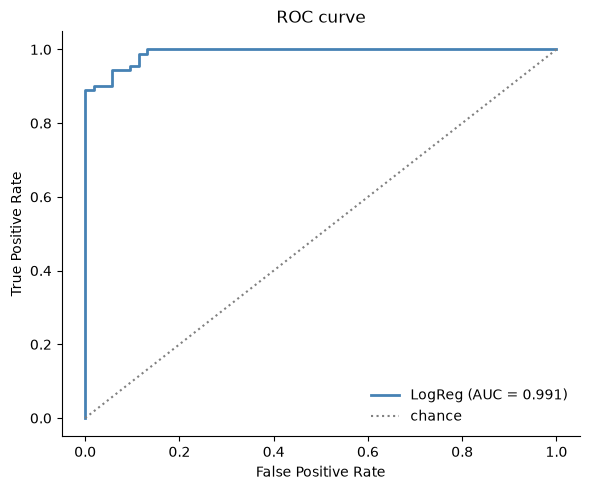

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_te, y_prob)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'LogReg (AUC = {roc_auc_score(y_te, y_prob):.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', label='chance')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 9. Multiclass — softmax regression

With K > 2 classes, the natural generalization is

    P(Y = k | X = x)  =  exp(wₖ⊤x) / Σⱼ exp(wⱼ⊤x)

This is **softmax regression** (a.k.a. multinomial logistic). The loss is
multinomial cross-entropy

    ℓ = -Σᵢ Σₖ yᵢₖ log p̂ᵢₖ

and is also convex. Most multiclass models in practice are one-vs-rest
logistic or softmax over the final layer of a neural network.

In [8]:
from sklearn.datasets import load_iris
X, y = load_iris().data, load_iris().target
clf = LogisticRegression(max_iter=500).fit(X, y)
print('iris accuracy:', clf.score(X, y))

iris accuracy: 0.9733333333333334


## 10. Calibration — when the probabilities matter

Sometimes you care about the *probability* P(y=1 | x), not just the class.
Two models with the same accuracy can have very different calibration.

- **Platt scaling** — fit a 1-d logistic on the scores.
- **Isotonic regression** — fit a monotone step function on the scores.
- **Temperature scaling** — divide logits by T before softmax; tune T on a
  held-out set. Cheap and surprisingly effective for neural nets.

Use `sklearn.calibration.calibration_curve` to plot observed vs predicted
frequency and check the diagonal.

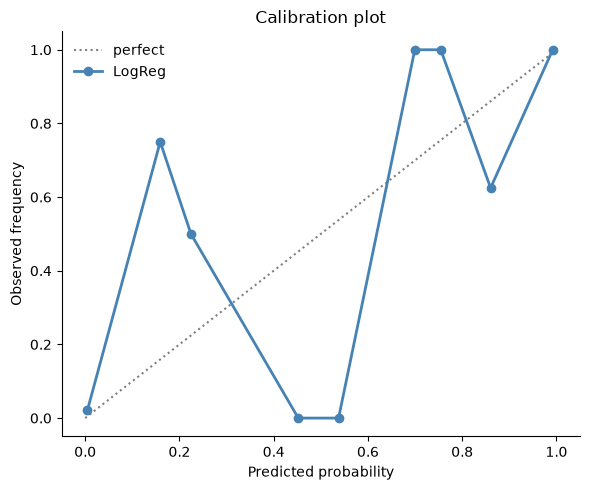

In [9]:
from sklearn.calibration import calibration_curve
fig, ax = plt.subplots(figsize=(6, 5))
prob_true, prob_pred = calibration_curve(y_te, y_prob, n_bins=10)
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', label='perfect')
ax.plot(prob_pred, prob_true, marker='o', color='steelblue', lw=2, label='LogReg')
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title('Calibration plot')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Summary

| Concept | Key point |
|---|---|
| Logistic | P(y=1\|x) = σ(w⊤x+b); loss is cross-entropy |
| LDA | Gaussian per class, shared Σ, linear boundary |
| QDA | Gaussian per class, separate Σ, quadratic boundary |
| Confusion matrix | TN/FP/FN/TP — basis for all metrics |
| ROC-AUC | Threshold-free ranking quality |
| Calibration | Are the probabilities right? Platt / isotonic / temperature |

**Next:** `07_resampling_and_validation.ipynb` — how to *honestly* measure
generalization.